# Réseau de neurones 

Objectif : entraîner **deux réseaux de neurones comparables** :
1. un modèle sur le CSV contenant **toutes les variables** ;
2. un modèle sur le CSV contenant les **variables sélectionnées**.

## Imports

In [ ]:
import os 
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print('TensorFlow version :', tf.__version__)

TensorFlow version : 2.21.0


## Paramètres

In [2]:
# Chemins vers CSV
CSV_ALL = 'exports/coordonnees_clean.csv'
CSV_SELECTED = 'exports/coordonnees_reduction.csv'

# Colonne cible
TARGET_COL = "label"

## Chargement des deux datasets

In [3]:
#chargement du dataset complet
df_all = pd.read_csv(CSV_ALL)
print("Dataset complet")
print("Taille :", df_all.shape)

y_all = df_all[TARGET_COL]
X_all = df_all.drop(columns=[TARGET_COL])

# On garde uniquement les variables numériques
X_all = X_all.select_dtypes(include=[np.number])

print("Nombre de variables :", X_all.shape[1])
print("Répartition des classes :")
display(y_all.value_counts())

Dataset complet
Taille : (284, 85)
Nombre de variables : 84
Répartition des classes :


label
yop_tchagui    146
ap_tchagui     138
Name: count, dtype: int64

In [4]:
# Chargement du dataste réduit
df_selected = pd.read_csv(CSV_SELECTED)
print("Dataset avec variables sélectionnées")
print("Taille :", df_selected.shape)

y_selected = df_selected[TARGET_COL]
X_selected = df_selected.drop(columns=[TARGET_COL])

# On garde uniquement les variables numériques
X_selected = X_selected.select_dtypes(include=[np.number])

print("Nombre de variables :", X_selected.shape[1])
print("Répartition des classes :")
display(y_selected.value_counts())

Dataset avec variables sélectionnées
Taille : (284, 72)
Nombre de variables : 71
Répartition des classes :


label
yop_tchagui    146
ap_tchagui     138
Name: count, dtype: int64

## Encodage de la cible

Un réseau de neurones travaille avec des nombres. On transforme donc les classes texte en labels numériques.

In [5]:
# L'encodage est appris sur le dataset complet puis réutilisé sur le dataset contenant uniquement les variables sélectionnées.
# Ainsi, les deux expériences utilisent exactement la même correspondance entre les classes et les valeurs numériques.

# Encodage de la cible
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_all)

print("Encodage des classes :")
for i, classe in enumerate(label_encoder.classes_):
    print(f"{classe} -> {i}")

Encodage des classes :
ap_tchagui -> 0
yop_tchagui -> 1


## Split train / test commun

Pour comparer correctement les deux modèles, on utilise les **mêmes indices de train/test** pour les deux CSV.

In [6]:
# Création d'un tableau contenant les indices des lignes
indices = np.arange(len(y_encoded))

# Séparation train/test
# stratify=y_encoded : conserve la même proportion de classes dans les deux ensembles
# test_size=0.25 : 25 % des données seront utilisées pour le test
# random_state : garantit la reproductibilité du découpage
train_idx, test_idx = train_test_split(
    indices,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)

print(f"Taille train : {len(train_idx)}")
print(f"Taille test  : {len(test_idx)}")

Taille train : 213
Taille test  : 71


## Préparation des données

On standardise les variables avec `StandardScaler`.

In [7]:
# Préparation des données - Dataset complet

# Séparation train / test
X_all_train = X_all.iloc[train_idx].copy()
X_all_test = X_all.iloc[test_idx].copy()

# Standardisation des variables
# Le scaler est uniquement sur les données de train afin d'éviter les fuites d'informations provenant du jeu de test.
scaler_all = StandardScaler()

X_all_train = scaler_all.fit_transform(X_all_train)
X_all_test = scaler_all.transform(X_all_test)

In [8]:
# Préparation des données - Dataset avec variables sélectionnées

# Séparation train / test
X_sel_train = X_selected.iloc[train_idx].copy()
X_sel_test = X_selected.iloc[test_idx].copy()

# Standardisation des variables
scaler_selected = StandardScaler()

X_sel_train = scaler_selected.fit_transform(X_sel_train)
X_sel_test = scaler_selected.transform(X_sel_test)

In [9]:
# Variable cible avec le même découpage train/test
y_train = y_encoded[train_idx]
y_test = y_encoded[test_idx]

## Création du réseau de neurones

On crée un réseau de neuronne. On utilise une fonction pour définir ce réseau, cela nous permet d'utiliser le même réseau pour les deux tests sur les différentes dataset pour garantir une comparaison équitable.

In [10]:
# Fonction qui construit le réseau de neuronnes
def build_model(input_dim, n_classes): #input_dim = nombre de variables en entrée / n_classes = nombre de classes à prédire
    # Chargement du model
    model = keras.Sequential()

    # Couche d'entrée
    model.add(layers.Input(shape=(input_dim,)))

    # Première couche cachée
    # On part sur une première couche a 32 neuronnes avec fonction d'activation relu
    model.add(layers.Dense(32, activation='relu')) 
    model.add(layers.Dropout(0.25))  # limite un peu le surapprentissage

    # Deuxième couche cachée
    model.add(layers.Dense(16, activation='relu'))
    model.add(layers.Dropout(0.20))

    # Couche de sortie
    model.add(layers.Dense(1, activation='sigmoid')) #Focntion d'activation Sigmoid adapté a une classification binaire
    loss = 'binary_crossentropy' #fonction de perte adaptée à une classification binaire
    metrics = ['accuracy']


    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001), #Algorithme qui adapte les poids
        loss=loss,
        metrics=metrics
    )

    return model

## Entraînement n°1 — toutes les variables

In [11]:
# construction du modele
model_all = build_model(
    input_dim=X_all_train.shape[1],
    n_classes=2
)

In [12]:
# Résumé du modele
model_all.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         2,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,265 (12.75 KB)

 Trainable params: 3,265 (12.75 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Entrainement du model
history_all = model_all.fit(
    
    X_all_train, # Variables d'entrée complètes
    y_train, # Classe attendue

    validation_split=0.2, # 20 % du jeu d'entraînement réservé à la validation
    epochs=150, # Nombre max de passages sur l'ensemble des données d'entraînement
    batch_size=16, # Nombre d'observations traitées avant une mise à jour des poids du réseau
    verbose=2 #Affichage de l'entrainement
)

Epoch 1/150
11/11 - 1s - 133ms/step - accuracy: 0.5412 - loss: 0.7077 - val_accuracy: 0.8372 - val_loss: 0.5901
Epoch 2/150
11/11 - 0s - 8ms/step - accuracy: 0.7000 - loss: 0.5692 - val_accuracy: 0.8605 - val_loss: 0.5555
Epoch 3/150
11/11 - 0s - 9ms/step - accuracy: 0.7824 - loss: 0.5188 - val_accuracy: 0.8605 - val_loss: 0.5208
Epoch 4/150
11/11 - 0s - 16ms/step - accuracy: 0.7706 - loss: 0.5016 - val_accuracy: 0.8605 - val_loss: 0.4841
Epoch 5/150
11/11 - 0s - 9ms/step - accuracy: 0.8353 - loss: 0.4263 - val_accuracy: 0.8605 - val_loss: 0.4499
Epoch 6/150
11/11 - 0s - 9ms/step - accuracy: 0.8471 - loss: 0.4000 - val_accuracy: 0.9070 - val_loss: 0.4314
Epoch 7/150
11/11 - 0s - 9ms/step - accuracy: 0.8588 - loss: 0.3723 - val_accuracy: 0.9302 - val_loss: 0.4119
Epoch 8/150
11/11 - 0s - 11ms/step - accuracy: 0.8471 - loss: 0.3538 - val_accuracy: 0.9302 - val_loss: 0.3967
Epoch 9/150
11/11 - 0s - 15ms/step - accuracy: 0.8706 - loss: 0.3358 - val_accuracy: 0.9302 - val_loss: 0.3818
Epoch

In [14]:
# Prédictions sur le jeu de test
y_pred_raw_all = model_all.predict(X_all_test)

# Comme la sortie est une sigmoid, on obtient une probabilité.
# On applique un seuil de 0.5 pour obtenir la classe finale.
y_pred_all = (y_pred_raw_all.ravel() >= 0.5).astype(int)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


In [15]:
# Évaluation du modèle
accuracy_all = accuracy_score(y_test, y_pred_all)

print(f"Accuracy test - Toutes les variables : {accuracy_all:.3f}")

print("\nRapport de classification :")
print(classification_report(
    y_test,
    y_pred_all,
    target_names=label_encoder.classes_
))

# Matrice de confusion
cm_all = confusion_matrix(y_test, y_pred_all)
print("Matrice de confusion :")
print(cm_all)

Accuracy test - Toutes les variables : 0.915

Rapport de classification :
              precision    recall  f1-score   support

  ap_tchagui       0.89      0.94      0.92        35
 yop_tchagui       0.94      0.89      0.91        36

    accuracy                           0.92        71
   macro avg       0.92      0.92      0.92        71
weighted avg       0.92      0.92      0.92        71

Matrice de confusion :
[[33  2]
 [ 4 32]]


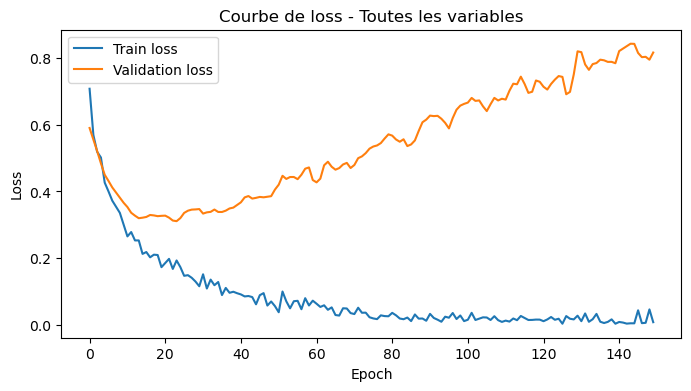

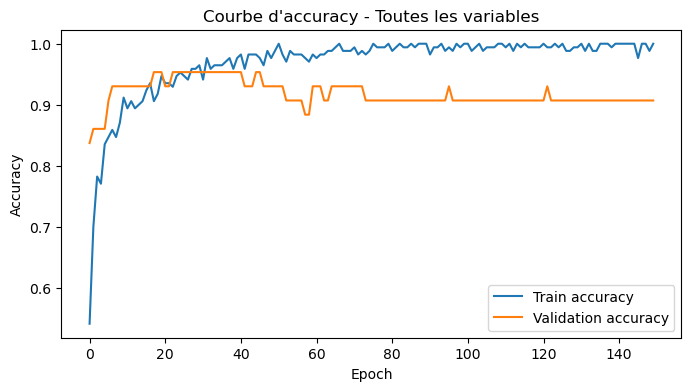

In [16]:
# Courbe de loss
plt.figure(figsize=(8, 4))
plt.plot(history_all.history["loss"], label="Train loss")
plt.plot(history_all.history["val_loss"], label="Validation loss")
plt.title("Courbe de loss - Toutes les variables")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Courbe d'accuracy
plt.figure(figsize=(8, 4))

plt.plot(history_all.history["accuracy"], label="Train accuracy")
plt.plot(history_all.history["val_accuracy"], label="Validation accuracy")

plt.title("Courbe d'accuracy - Toutes les variables")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

#### Analyse des courbes d'apprentissage

Les courbes montrent que le modèle apprend correctement durant les premières epochs : la loss d'entraînement et la loss de validation diminuent simultanément tandis que l'accuracy augmente.

Cependant, après une vingtaine d'epochs, la loss de validation commence à augmenter alors que la loss d'entraînement continue de diminuer. Ce comportement est caractéristique d'un surapprentissage : le modèle mémorise progressivement les données d'entraînement et perd en capacité de généralisation.

Une solution consiste à réduire manuellement le nombre d'epochs. Cependant, cette approche nécessite d'analyser les courbes à chaque nouvel entraînement. Nous allons donc utiliser le mécanisme d'**Early Stopping** proposé par Keras. Celui-ci surveille automatiquement les performances sur l'ensemble de validation et interrompt l'entraînement lorsque celles-ci n'améliorent plus le modèle. Cela permet de conserver automatiquement la version du réseau offrant le meilleur compromis entre apprentissage et généralisation.

In [17]:
# EarlyStopping :
# surveille la loss de validation et arrête l'entraînement lorsque celle-ci n'améliore plus le modèle.

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss", # Métrique surveillée (loss calculée sur l'ensemble de validation)
    patience=15, # Nombre d'epochs sans amélioration autorisées avant d'arrêter l'entraînement
    restore_best_weights=True # Recharge automatiquement les poids correspondant à la meilleure valeur observée de val_loss
)

In [18]:
# Construction d'un nouveau modèle
model_all_es = build_model(
    input_dim=X_all_train.shape[1],
    n_classes=2
)

# Entrainement du modèle
history_all_es = model_all_es.fit(

    X_all_train, # Variables d'entrée complètes
    y_train, # Classe attendue

    validation_split=0.2, # 20 % du jeu d'entraînement réservé à la validation
    epochs=150, # Nombre maximum d'epochs
    batch_size=16, # Taille des mini-batchs
    callbacks=[early_stopping], #arret prématuré de l'entrainement
    verbose=0 # Affichage de l'entraînement
)

In [19]:
# Prédictions sur le jeu de test
y_pred_raw_all_es = model_all_es.predict(X_all_test)

# Seuil de 0.5 car sortie sigmoid
y_pred_all_es = (y_pred_raw_all_es.ravel() >= 0.5).astype(int)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step 


In [20]:
# Évaluation du modèle avec EarlyStopping
accuracy_all_es = accuracy_score(y_test, y_pred_all_es)

print(f"Accuracy test - Toutes les variables avec EarlyStopping : {accuracy_all_es:.3f}")

print("\nRapport de classification :")
print(classification_report(
    y_test,
    y_pred_all_es,
    target_names=label_encoder.classes_
))

cm_all_es = confusion_matrix(y_test, y_pred_all_es)
print("Matrice de confusion :")
print(cm_all_es)

Accuracy test - Toutes les variables avec EarlyStopping : 0.944

Rapport de classification :
              precision    recall  f1-score   support

  ap_tchagui       0.92      0.97      0.94        35
 yop_tchagui       0.97      0.92      0.94        36

    accuracy                           0.94        71
   macro avg       0.94      0.94      0.94        71
weighted avg       0.95      0.94      0.94        71

Matrice de confusion :
[[34  1]
 [ 3 33]]


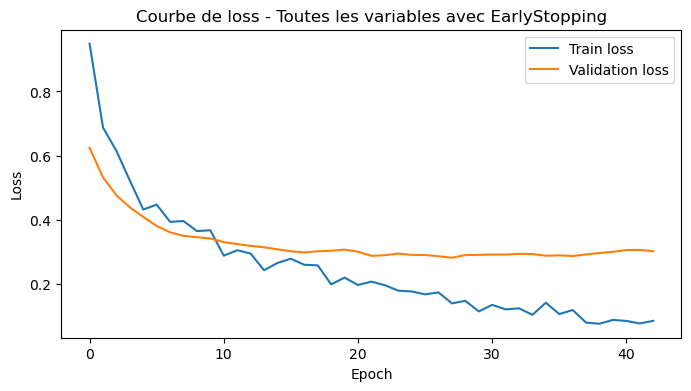

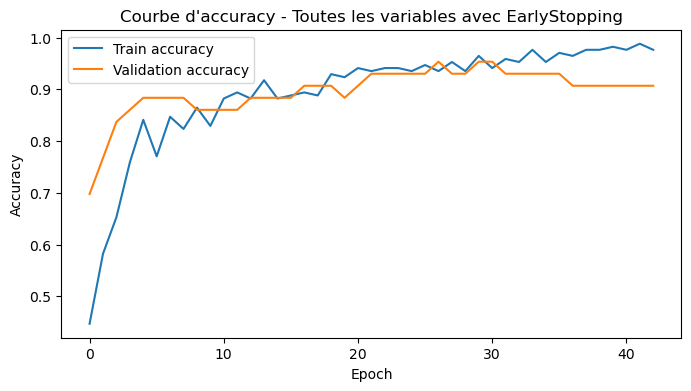

In [21]:
# Courbe de loss
plt.figure(figsize=(8, 4))
plt.plot(history_all_es.history["loss"], label="Train loss")
plt.plot(history_all_es.history["val_loss"], label="Validation loss")
plt.title("Courbe de loss - Toutes les variables avec EarlyStopping")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Courbe d'accuracy
plt.figure(figsize=(8, 4))
plt.plot(history_all_es.history["accuracy"], label="Train accuracy")
plt.plot(history_all_es.history["val_accuracy"], label="Validation accuracy")
plt.title("Courbe d'accuracy - Toutes les variables avec EarlyStopping")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

#### Analyse des courbes avec EarlyStopping

L'ajout du mécanisme d'**Early Stopping** permet d'interrompre automatiquement l'entraînement lorsque les performances sur l'ensemble de validation cessent de s'améliorer.
Les meilleures performances de validation semblent être atteintes entre 20 et 30 epochs. L'utilisation de l'Early Stopping confirme donc les observations réalisées lors de l'analyse manuelle des courbes d'apprentissage.

## Entraînement n°2 — variables sélectionnées

In [22]:
# Construction du modèle - Variables sélectionnées
model_sel = build_model(
    input_dim=X_sel_train.shape[1],
    n_classes=2
)

# Early stopping
early_stopping_sel = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

# Entrainement du modele
history_sel = model_sel.fit(
    X_sel_train,
    y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=16,
    callbacks=[early_stopping_sel],
    verbose=0
)

# Prédictions sur le jeu de test
y_pred_raw_sel = model_sel.predict(X_sel_test)

# Transformation des probabilités en classes
y_pred_sel = (y_pred_raw_sel.ravel() >= 0.5).astype(int)

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/stepWARNING:tensorflow:6 out of the last 9 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000002225B2B04A0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


In [23]:
# Evaluation du modele
accuracy_sel = accuracy_score(y_test, y_pred_sel)

print(f"Accuracy test - Variables sélectionnées : {accuracy_sel:.3f}")

print("\nRapport de classification :")
print(classification_report(
    y_test,
    y_pred_sel,
    target_names=label_encoder.classes_
))

# Matrice de confusion
cm_sel = confusion_matrix(y_test, y_pred_sel)
print("Matrice de confusion :")
print(cm_sel)

Accuracy test - Variables sélectionnées : 0.901

Rapport de classification :
              precision    recall  f1-score   support

  ap_tchagui       0.91      0.89      0.90        35
 yop_tchagui       0.89      0.92      0.90        36

    accuracy                           0.90        71
   macro avg       0.90      0.90      0.90        71
weighted avg       0.90      0.90      0.90        71

Matrice de confusion :
[[31  4]
 [ 3 33]]


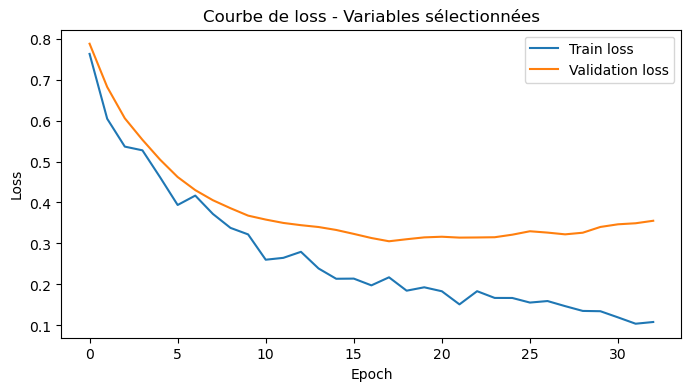

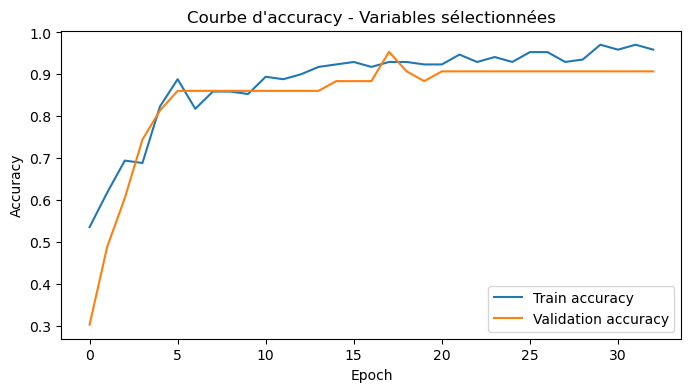

In [24]:
# Courbe de loss
plt.figure(figsize=(8, 4))
plt.plot(history_sel.history["loss"], label="Train loss")
plt.plot(history_sel.history["val_loss"], label="Validation loss")
plt.title("Courbe de loss - Variables sélectionnées")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Courbe d'accuracy
plt.figure(figsize=(8, 4))
plt.plot(history_sel.history["accuracy"], label="Train accuracy")
plt.plot(history_sel.history["val_accuracy"], label="Validation accuracy")
plt.title("Courbe d'accuracy - Variables sélectionnées")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Sélection du modèle final

Parmi les différentes architectures testées, le réseau composé de deux couches cachées de 32 puis 16 neurones associé à un mécanisme d'Early Stopping a été retenu pour la suite du projet.

Cette architecture obtient les meilleures performances sur l'ensemble des coordonnées disponibles tout en conservant une complexité limitée. Le recours à l'Early Stopping permet également de limiter le surapprentissage observé lors des premiers entraînements.

## Sauvegarde du modele

In [25]:
# Sauvegardee de la liste des colonnes
feature_columns = X_all.columns.tolist()
joblib.dump(feature_columns, "models/feature_columns.pkl")

['models/feature_columns.pkl']

In [26]:
# On sauvegarde les labales
joblib.dump(label_encoder.classes_, "models/classes.pkl")

['models/classes.pkl']

In [27]:
# Sauvegarde du réseau de neurones
model_all_es.save("models/modele_taekwondo.keras")

# Sauvegarde du scaler utilisé pour la standardisation
joblib.dump(scaler_all, "models/scaler_taekwondo.pkl")

['models/scaler_taekwondo.pkl']